<a href="https://colab.research.google.com/github/shardas06543/Master-s-Thesis/blob/main/Randomness_%26_Diversity_(1)_TF_IDF%2C_N_gram%2C_word_cloud_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF n-gram Analysis, Word Clouds

This notebook is for calculating the randomness and diversity of the LLM-generated data.


**Import all previous libraries**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import duckdb
import numpy as np
from google.colab import drive
import torch



In [ ]:
!pip install duckdb

**Mount the Google Drive**

In [ ]:
drive.mount('/content/drive')
synth_all = pd.read_csv('/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/train_100%_synth.csv')
synth_minority = synth_all[synth_all["Rating"].isin([1, 2, 3])]
real = pd.read_csv('/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/train_100%_real.csv')
real_minority = real[real["Rating"].isin([1, 2, 3])]


Mounted at /content/drive


In [ ]:
# real_only = master_frame[(master_frame["Data Type"] == "Real")].sample(frac = 1, random_state=42).reset_index(drop = True)
# synthetic_only = master_frame[(master_frame["Data Type"] != "Real")].sample(frac = 1, random_state=42).reset_index(drop = True)
# real_only["Rating"] = real_only["Rating"].astype(int)
# synthetic_only["Rating"] = synthetic_only["Rating"].fillna(0).astype(int)
# synthetic_minority = synthetic_only[synthetic_only["Rating"].isin([1, 2, 3])]


**Word length distribution for minority classes**




/tmp/ipykernel_18261/2268331812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_minority["review_word_length"] = [len(review.split()) for review in real_minority["Review"]]


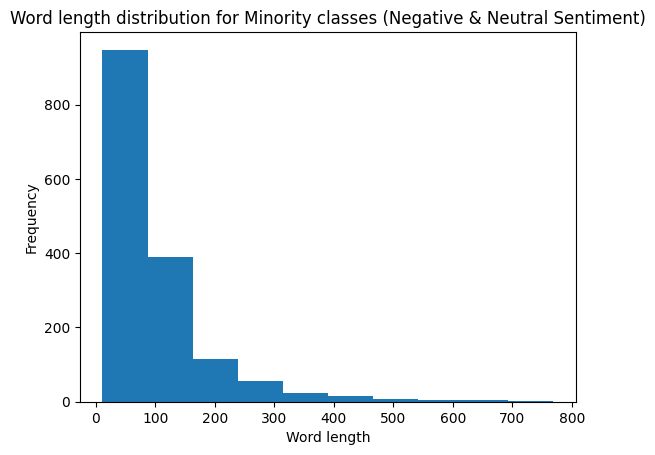

In [ ]:
real_minority["review_word_length"] = [len(review.split()) for review in real_minority["Review"]]
real_minority['review_word_length'].plot(kind='hist', bins=10)
plt.title('Word length distribution for Minority classes (Negative & Neutral Sentiment)')
plt.xlabel('Word length')
plt.ylabel('Frequency')
plt.show()

**character length distribution**

/tmp/ipykernel_18261/1377624806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_minority['review_character_length'] = [len(review) for review in real_minority['Review']] #Character length


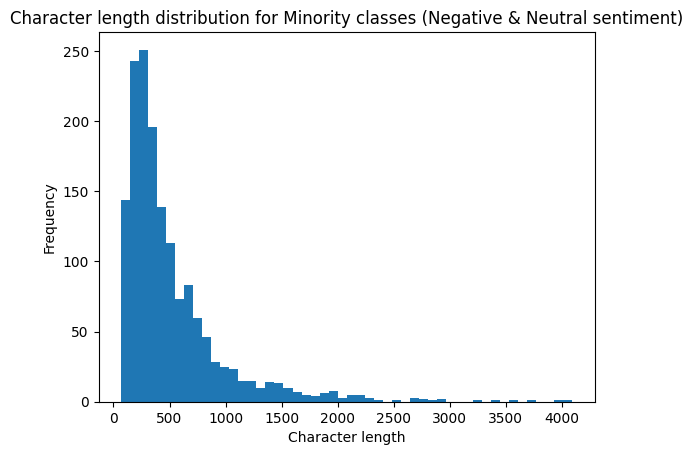

In [ ]:
real_minority['review_character_length'] = [len(review) for review in real_minority['Review']] #Character length
real_minority['review_character_length'].plot(kind='hist', bins=50)
plt.title('Character length distribution for Minority classes (Negative & Neutral sentiment)')
plt.xlabel('Character length')
plt.ylabel('Frequency')
plt.show()

**Vectorize the raw text data into numerical format for machine interpretability, using Tf-idf**


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS.union({'did', 'didn', 'don', 'just', 'like'}))

vectorizer_real = TfidfVectorizer(stop_words = custom_stopwords, lowercase=True, smooth_idf=True, norm = 'l2', min_df = .1, max_df = 0.85, analyzer="word", ngram_range=(1,3))

real_minority_cleaned = real_minority.dropna(subset=["Review"])
synth_minority_cleaned = synth_minority.dropna(subset=["Review"])

data_real = vectorizer_real.fit_transform(real_minority_cleaned["Review"])
data_synth = vectorizer_real.transform(synth_minority_cleaned["Review"])

In [ ]:
vectorizer_real.get_feature_names_out()

array(['cruise', 'day', 'food', 'gift', 'glacier', 'good', 'got', 'great',
       'hotel', 'juneau', 'minutes', 'money', 'nice', 'people', 'place',
       'really', 'restaurant', 'ride', 'room', 'service', 'ship', 'shop',
       'staff', 'time', 'told', 'tour', 'tram', 'trip', 'view', 'views',
       'way', 'went', 'worth'], dtype=object)

**convert the results from vectorizer1 into a dataframe**

In [ ]:

df_real = pd.DataFrame(data_real.toarray(), columns = vectorizer_real.get_feature_names_out())
df_synthetic = pd.DataFrame(data_synth.toarray(), columns = vectorizer_real.get_feature_names_out())





**Get the mean, median, mode, standard deviation for each column**

Each column means "across all the reviews in the dataset"

In [ ]:
analyze_unigram_TF_IDF = pd.DataFrame(vectorizer_real.idf_, index = vectorizer_real.get_feature_names_out(), columns = ["IDF Score"])
analyze_unigram_TF_IDF["Mean TF-IDF"] = list(df_real.mean())
analyze_unigram_TF_IDF["Median TF-IDF"] = list(df_real.median())
analyze_unigram_TF_IDF["Std TF-IDF"] = list(df_real.std())
analyze_unigram_TF_IDF["Sum TF-IDF (by word)"] = list(df_real.sum())

# NOTE - Mode tells you which TF-IDF score appears the most frequent for a specific vocabulary word.

analyze_unigram_TF_IDF.head()

,IDF Score,Mean TF-IDF,Median TF-IDF,Std TF-IDF,Sum TF-IDF (by word)
cruise,2.599260,0.072885,0.0,0.163507,113.919071
day,2.805926,0.058963,0.0,0.153855,92.159165
food,2.956839,0.073930,0.0,0.199927,115.553115
gift,3.286098,0.038401,0.0,0.121498,60.020384
glacier,2.681679,0.110346,0.0,0.251688,172.470199


In [ ]:
analyze_unigram_TF_IDF2 = pd.DataFrame(vectorizer_real.idf_, index = vectorizer_real.get_feature_names_out(), columns = ["IDF Score"])
analyze_unigram_TF_IDF2["Mean TF-IDF"] = list(df_synthetic.mean())
analyze_unigram_TF_IDF2["Median TF-IDF"] = list(df_synthetic.median())
analyze_unigram_TF_IDF2["Std TF-IDF"] = list(df_synthetic.std())
analyze_unigram_TF_IDF2["Sum TF-IDF (by word)"] = list(df_synthetic.sum())

# NOTE - Mode tells you which TF-IDF score appears the most frequent for a specific vocabulary word.

analyze_unigram_TF_IDF2.head()

,IDF Score,Mean TF-IDF,Median TF-IDF,Std TF-IDF,Sum TF-IDF (by word)
cruise,2.599260,0.007312,0.0,0.046171,10.792869
day,2.805926,0.058473,0.0,0.125512,86.306605
food,2.956839,0.017148,0.0,0.079973,25.309893
gift,3.286098,0.059297,0.0,0.120357,87.522868
glacier,2.681679,0.240037,0.0,0.298040,354.294519


**plot the IDF score for each word in the unigram TF_IDF matrix**

In [ ]:
analyze_unigram_TF_IDF.sort_values(by = "IDF Score", ascending = False)
analyze_unigram_TF_IDF2.sort_values(by = "IDF Score", ascending = False)


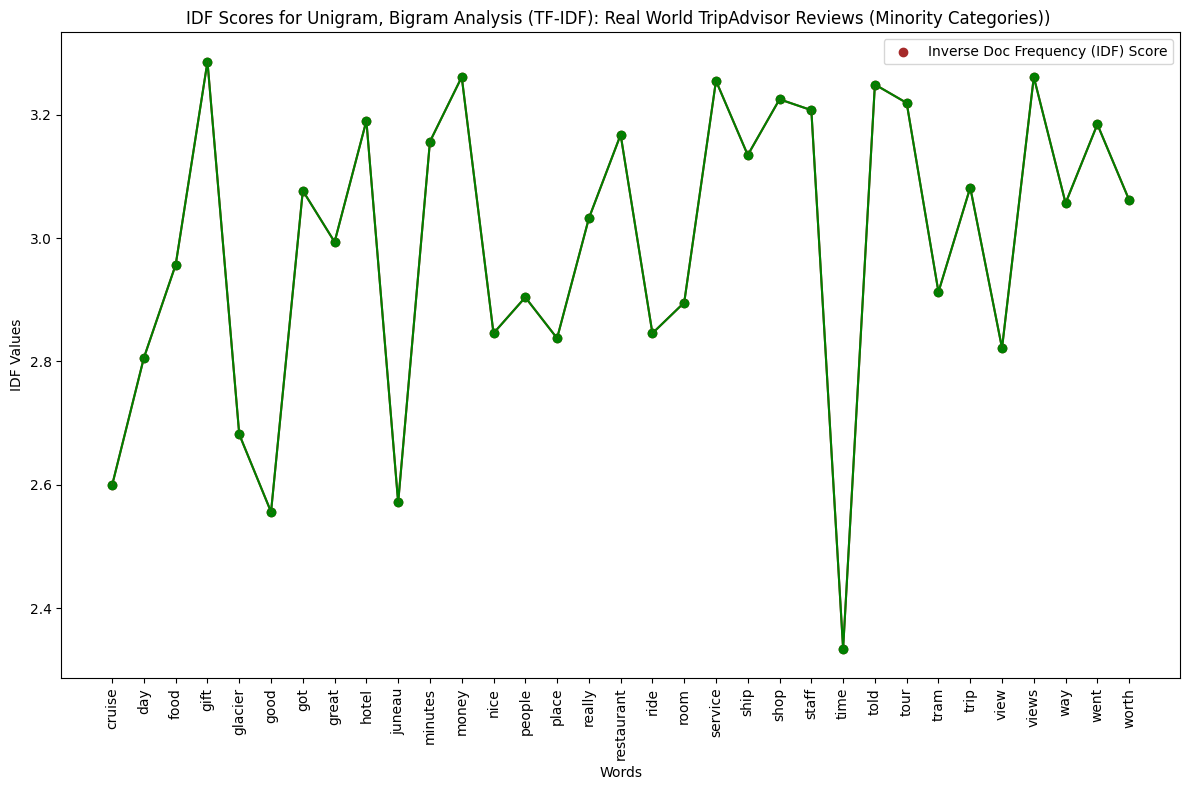

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(analyze_unigram_TF_IDF.index, analyze_unigram_TF_IDF['IDF Score'], label = "IDF Score", color = "Brown")
plt.plot(analyze_unigram_TF_IDF.index, analyze_unigram_TF_IDF['IDF Score'], label = "IDF Score", color = "Brown")
plt.scatter(analyze_unigram_TF_IDF2.index, analyze_unigram_TF_IDF2['IDF Score'], label = "IDF Score2", color = "Green")
plt.plot(analyze_unigram_TF_IDF2.index, analyze_unigram_TF_IDF2['IDF Score'], label = "IDF Score2", color = "Green")

_ = plt.xticks(rotation=90)

plt.legend(["Inverse Doc Frequency (IDF) Score"])
plt.title("IDF Scores for (TF-IDF) values: Real World TripAdvisor Reviews (Minority Categories)) ")
plt.xlabel("Words")
plt.ylabel("IDF Values")
plt.tight_layout()



**plot descriptive stats for the TF-IDF unigram analysis as a line plot**


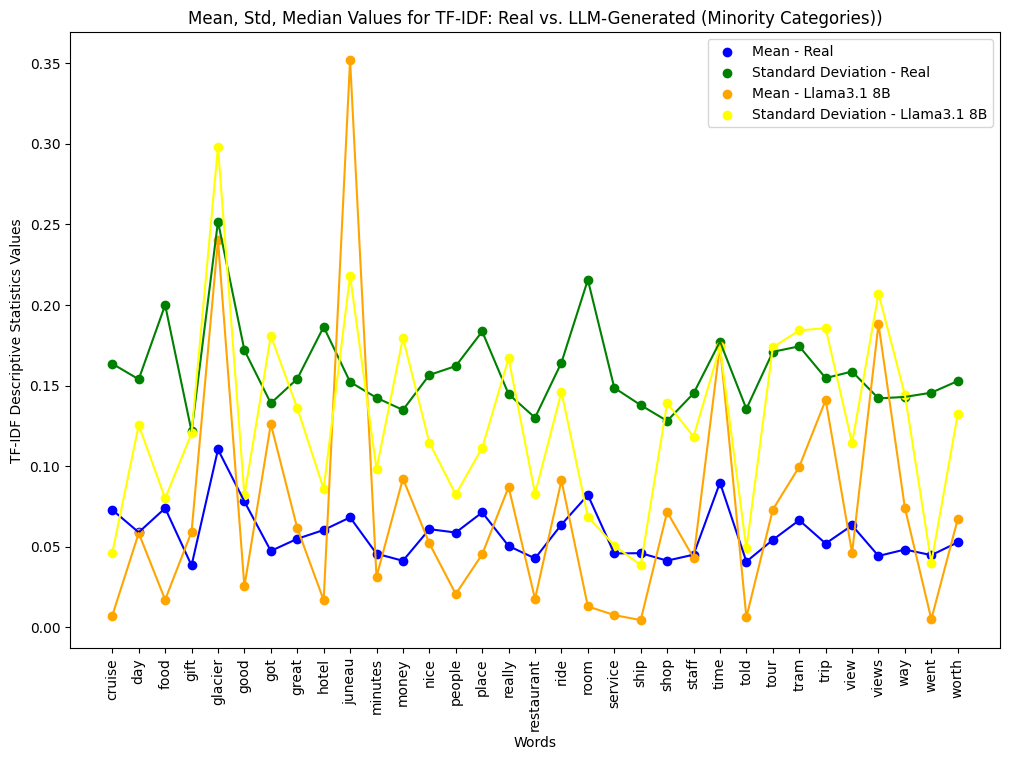

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(analyze_unigram_TF_IDF.index, analyze_unigram_TF_IDF["Mean TF-IDF"], label="Mean", color = "Blue")
plt.scatter(analyze_unigram_TF_IDF.index, analyze_unigram_TF_IDF["Std TF-IDF"], label="Std", color = "Green")

plt.scatter(analyze_unigram_TF_IDF2.index, analyze_unigram_TF_IDF2["Mean TF-IDF"], label="Mean2", color = "Orange")
plt.scatter(analyze_unigram_TF_IDF2.index, analyze_unigram_TF_IDF2["Std TF-IDF"], label="Std2", color = "Yellow")


plt.plot(analyze_unigram_TF_IDF["Mean TF-IDF"], label="Mean", color = "Blue")
plt.plot(analyze_unigram_TF_IDF["Std TF-IDF"], label="Std", color = "Green")
plt.plot(analyze_unigram_TF_IDF2["Mean TF-IDF"], label="Mean2", color = "Orange")
plt.plot(analyze_unigram_TF_IDF2["Std TF-IDF"], label="Std2", color = "Yellow")

plt.legend(["Mean - Real", "Standard Deviation - Real", "Mean - Llama3.1 8B", "Standard Deviation - Llama3.1 8B" ])
plt.title("Mean, Std, Median Values for TF-IDF: Real vs. LLM-Generated (Minority Categories))")
plt.xlabel("Words")
plt.ylabel("TF-IDF Descriptive Statistics Values")
_ = plt.xticks(rotation=90)



**plot sum for the TF-IDF (unigram, bigram analysis)**

High sum = The word holds signifcant meaning within the corpus. It serves as a driving factor amongst tourists in Juneau

Low sum = The word is rare and does not hold much significance


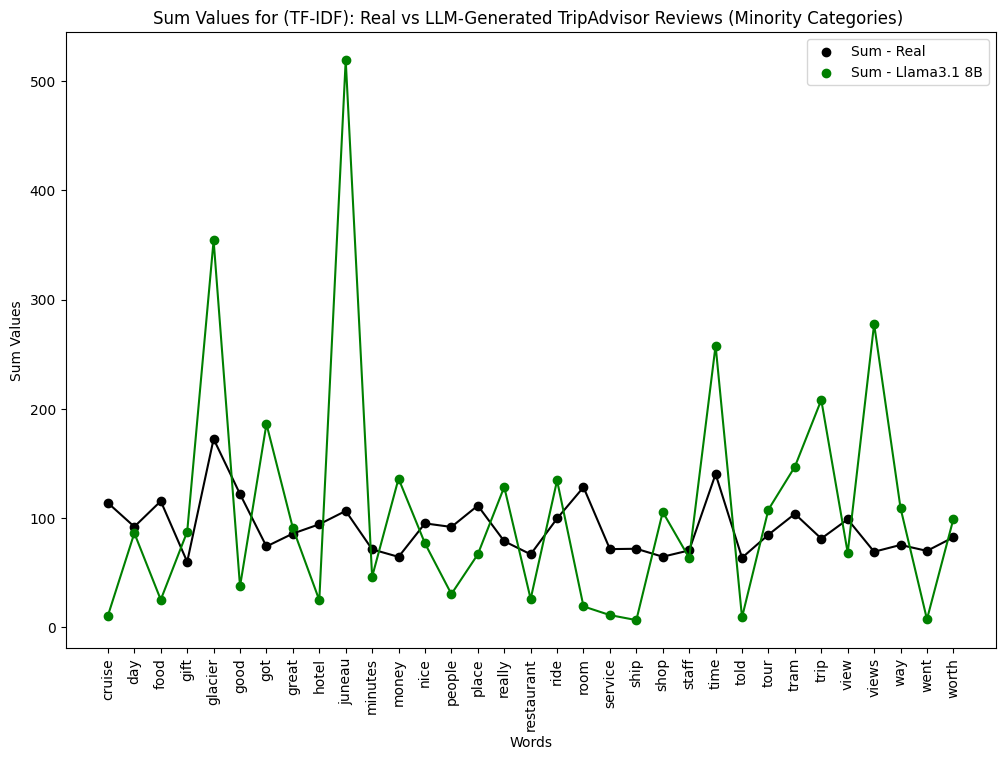

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(analyze_unigram_TF_IDF.index, analyze_unigram_TF_IDF["Sum TF-IDF (by word)"], label="Sum - Real",  color = "Black")
plt.plot(analyze_unigram_TF_IDF["Sum TF-IDF (by word)"], color = "Black")
plt.scatter(analyze_unigram_TF_IDF2.index, analyze_unigram_TF_IDF2["Sum TF-IDF (by word)"], label="Sum - Llama3.1 8B",  color = "Green")
plt.plot(analyze_unigram_TF_IDF2["Sum TF-IDF (by word)"], color = "Green")
plt.legend(["Sum"])
plt.title("Sum Values for (TF-IDF): Real vs LLM-Generated TripAdvisor Reviews (Minority Categories) ")
plt.legend()
plt.xlabel("Words")
plt.ylabel("Sum Values")
_ = plt.xticks(rotation=90)


**get a word cloud based on tf-idf sum values (sum the Tf-idf scores for each word (column) )**

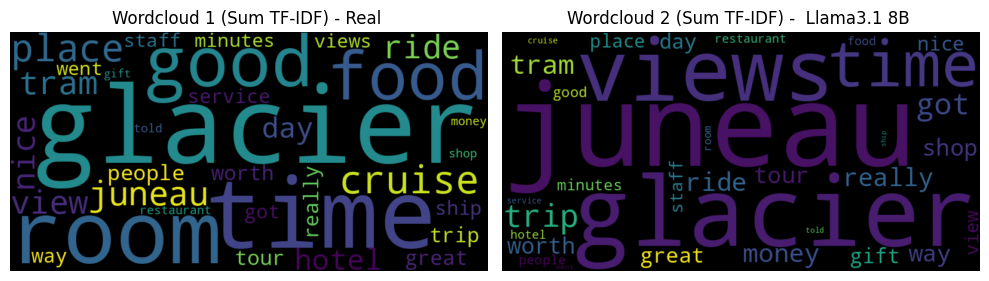

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF["Sum TF-IDF (by word)"])
wordcloud2 = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF2["Sum TF-IDF (by word)"])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Wordcloud 1 (Sum TF-IDF) - Real ")

axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Wordcloud 2 (Sum TF-IDF) -  Llama3.1 8B ")

plt.tight_layout()



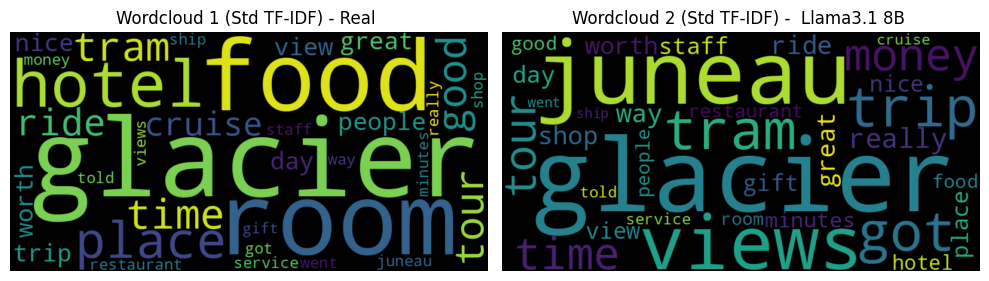

In [ ]:

wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF["Std TF-IDF"])
wordcloud2 = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF2["Std TF-IDF"])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Wordcloud 1 (Std TF-IDF) - Real ")

axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Wordcloud 2 (Std TF-IDF) -  Llama3.1 8B ")
plt.axis('off')

plt.tight_layout()

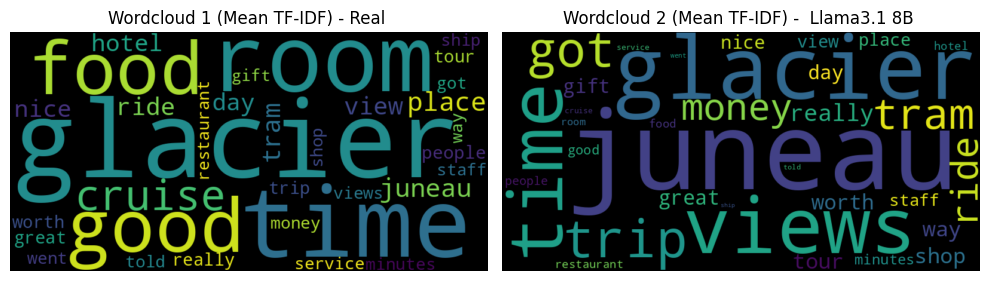

In [ ]:


wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF["Mean TF-IDF"])
wordcloud2 = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF2["Mean TF-IDF"])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Wordcloud 1 (Mean TF-IDF) - Real ")

axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Wordcloud 2 (Mean TF-IDF) -  Llama3.1 8B ")
plt.axis('off')

plt.tight_layout()

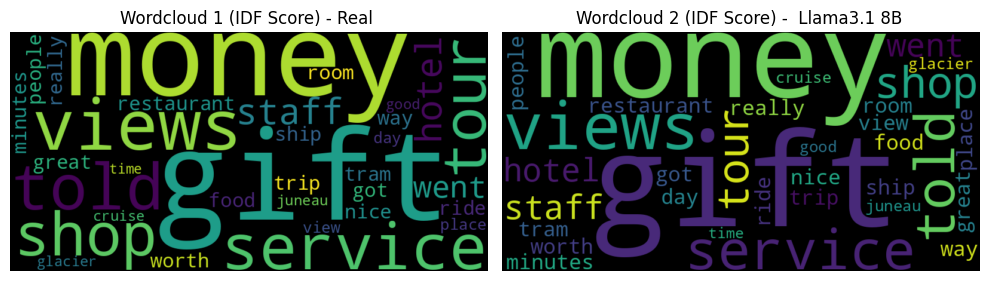

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF["IDF Score"])
wordcloud2 = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(analyze_unigram_TF_IDF2["IDF Score"])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Wordcloud 1 (IDF Score) - Real ")

axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Wordcloud 2 (IDF Score) -  Llama3.1 8B ")
plt.axis('off')

plt.tight_layout()